# DBSCAN Project - Iris Dataset

The goal of this notebook is to use Scikit-Learn's **DBSCAN and HDBSCAN** models to implement a complete machine learning project using Scikit-Learn's Iris dataset.

## 1. Imports

In [13]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score

from hdbscan import HDBSCAN

## 2. Load dataset

In [2]:
df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)
df['target'] = load_iris().target 

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (150, 5)
Head:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Description:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000 

In [5]:
# Prepare the data: keep features
X = df.drop("target", axis=1).values # features
y_true = df["target"].values # target

In [6]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Preprocessing

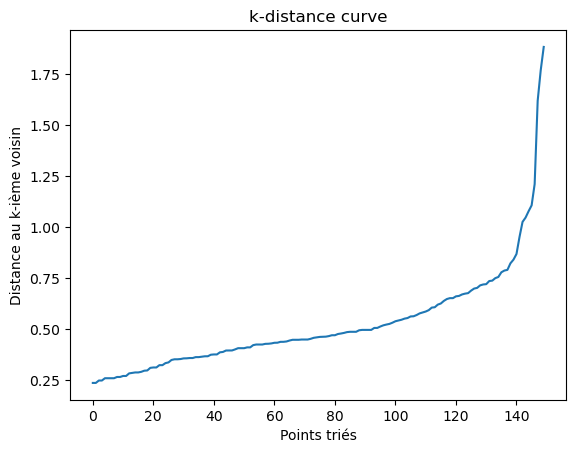

In [10]:
# Elbow method to find best k value
k = 5
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, indices = nn.kneighbors(X_scaled)

k_distances = distances[:, k-1]
k_distances_sorted = np.sort(k_distances)

plt.plot(k_distances_sorted)
plt.xlabel("Points triés")
plt.ylabel("Distance au k-ième voisin")
plt.title("k-distance curve")
plt.show()

The bend (elbow) is visible around **0.5–0.6**, where the curve begins to rise more sharply before the final increase.

## 4. Fit DBSCAN and HDBSCAN models

In [11]:
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# HDBSCAN
hdbscan = HDBSCAN(min_cluster_size=10, min_samples=5)
hdbscan_labels = hdbscan.fit_predict(X_scaled)

print("DBSCAN clusters:", np.unique(dbscan_labels))
print("HDBSCAN clusters:", np.unique(hdbscan_labels))

DBSCAN clusters: [-1  0  1]
HDBSCAN clusters: [-1  0  1]


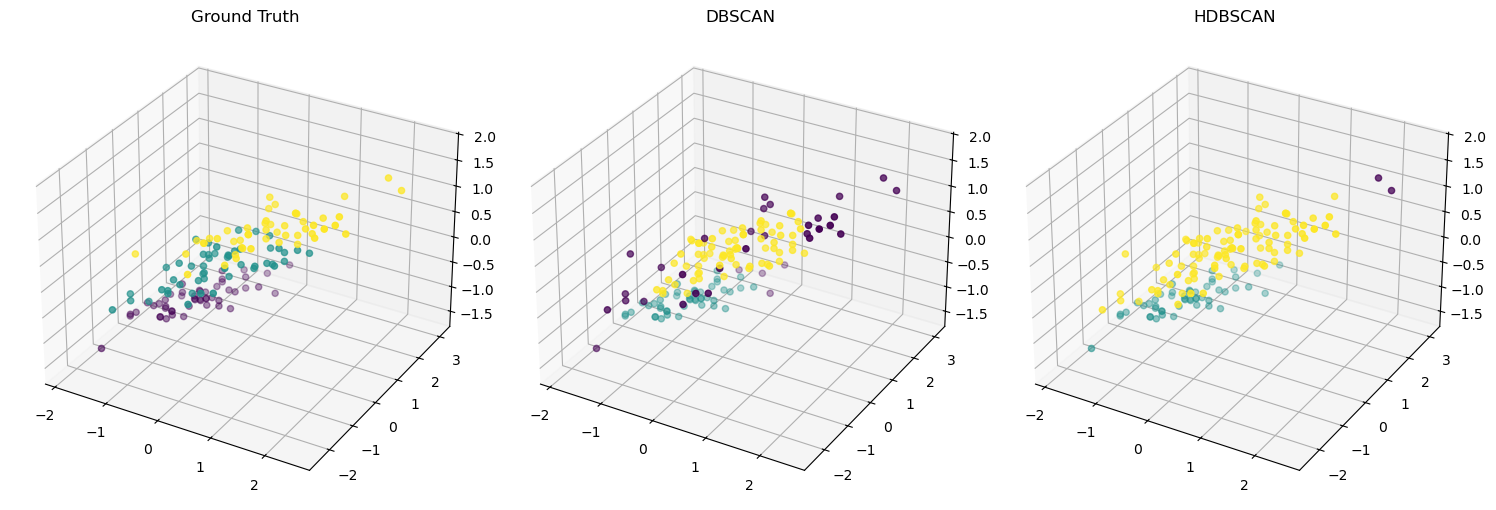

In [12]:
# Visualization in 3D 
fig = plt.figure(figsize=(15, 5))

# Ground truth
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=y_true, cmap='viridis')
ax1.set_title("Ground Truth")

# DBSCAN
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=dbscan_labels, cmap='viridis')
ax2.set_title("DBSCAN")

# HDBSCAN
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=hdbscan_labels, cmap='viridis')
ax3.set_title("HDBSCAN")

plt.tight_layout()
plt.show()

**Observations:**

- The ground truth has **three distinct classes**.

- DBSCAN and HDBSCAN identify several clusters, but these are distinct from those in the ground truth. 

- **HDBSCAN highlights 2 main classes**, including 2 points categorized as outliers. 

- **DBSCAN highlights 3 overlapping classes** that do not correspond to those in the ground truth. We can also assume that the purple points are outliers. In this case, HDBSCAN clearly has less noise (fewer isolated points) than DBSCAN.

This is expected behavior on the Iris dataset since the versicolor and virginica classes partially overlap, so their density boundaries are not sharp.

In [ ]:
# ARI score
ari_dbscan = adjusted_rand_score(y_true, dbscan_labels)
ari_hdbscan = adjusted_rand_score(y_true, hdbscan_labels)

print(f"ARI DBSCAN:  {ari_dbscan:.3f}")
print(f"ARI HDBSCAN: {ari_hdbscan:.3f}")

ARI DBSCAN:  0.442
ARI HDBSCAN: 0.564


**ARI (Adjusted Rand Index)** measures the **similarity** between two label assignments, in this case, the identified clusters versus the true classes.

The basic idea: for each pair of points, do the two assignments agree? 
- Same cluster in both → agreement. 
- Different clusters in both → agreement. 
- One in the same cluster, the other not → disagreement.

The “Adjusted” term corrects for chance—random clustering yields ARI ≈ 0.

**Interpretation:**

| Score | Meaning |
|---|---|
| 1.0 | Perfect clustering—identical to the ground truth |
| 0.0 | No better than random |
| < 0 | Worse than random |

So:
- DBSCAN at 0.442 → clustering partially consistent with the true classes.
- HDBSCAN at 0.564 → better, but far from perfect, normal given the *versicolor*/*virginica* overlap.

**Important limitation**: ARI requires a ground truth. In real-world production, we don’t have the true classes, otherwise we’d be doing classification, not clustering. ARI is only used for evaluation on benchmarks.